In [200]:
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset
from torch.utils.data import DataLoader
import torch.nn.functional as F

In [201]:
#定义简单神经网络类
class SNN(nn.Module):
    def __init__(self, number_input, number_output):
        super().__init__()
        self.layers=nn.Sequential(
            nn.Linear(number_input,30),#第一层
            nn.ReLU(),
            nn.Linear(30,20),
            nn.ReLU(),#第二层S
            nn.Linear(20,number_output)
        )
    def forward(self,x):
        logits=self.layers(x)
        return logits


In [202]:
#定义数据集类
class Sdataset(Dataset):
    def __init__(self,X,y):
        super().__init__()
        self.features=X
        self.labels=y
    def __getitem__(self, index):
        return self.features[index],self.labels[index]
    def __len__(self):
        return self.labels.shape[0]

In [203]:
#小型试验数据集
X_train = torch.tensor([
    [-1.2, 3.1],
    [-0.9, 2.9],
    [-0.5, 2.6],
    [2.3, -1.1],
    [2.7, -1.5]
])
y_train = torch.tensor([0, 0, 0, 1, 1])

X_test = torch.tensor([
    [-0.8, 2.8],
    [2.6, -1.6],
])
y_test = torch.tensor([0, 1])


In [204]:
#实例化神经网络，数据集实例
torch.manual_seed(123)
snnmodule=SNN(number_input=2,number_output=2)
train_ds=Sdataset(X_train,y_train)
test_ds=Sdataset(X_test,y_test)

In [205]:
#实例化数据加载器
train_loader=DataLoader(
    dataset=train_ds,
    batch_size=2,
    shuffle=True,
    num_workers=0,
    #drop_last=True
)
test_loader=DataLoader(
    dataset=test_ds,
    batch_size=2,
    shuffle=False,
    num_workers=0
)

In [206]:
#设置优化器
optimizer=torch.optim.SGD(snnmodule.parameters(),lr=0.5)

In [207]:
#训练模型
num_epochs=3
loss_list=[]
snnmodule.train()
for epoch in range(num_epochs):
    snnmodule.train()
    for batch_idx,(features,labels) in enumerate(train_loader):
        logits=snnmodule(features)
        loss=F.cross_entropy(logits,labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        #print(f'轮次:{epoch+1} 批次:{batch_idx+1} loss:{loss.item():.3f}'
        loss_list.append(round(loss.item(),2))

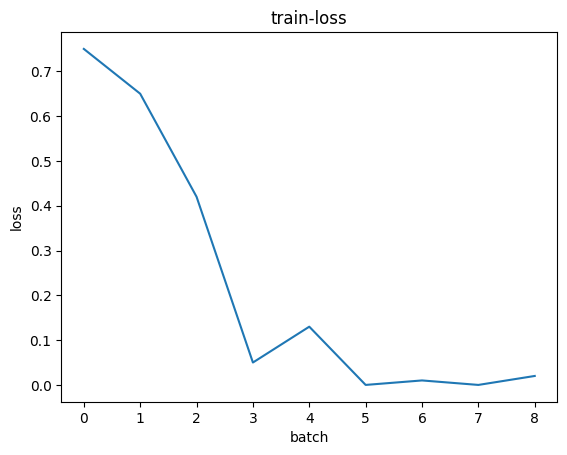

In [208]:
#画损失曲线
import matplotlib.pyplot as plt
plt.plot(loss_list)
plt.xlabel('batch')
plt.ylabel('loss')
plt.title('train-loss')
plt.show()

In [232]:
#评估函数
def compute_accuracy(model,dataloader):
    model.eval()
    correct=0
    total_examples=0
    with torch.no_grad():
        for features,labels in dataloader:
        
            logits=model(features)
            predictions=torch.argmax(logits,dim=1)
            correct+=torch.sum(predictions==labels)
            total_examples+=labels.shape[0]
    return (correct/total_examples).item()

In [ ]:
#评估模型
compute_accuracy(snnmodule,test_loader)

1.0

In [ ]:
#保存及加载模型
#torch.save(snnmodule.state_dict(),r'D:\project\llmstudy\snn.pth')
#snnmodule=SNN(2,2)
#snnmodule.load_state_dict(torch.load(r'D:\project\llmstudy\snn.pth'))